#**Project title : "AI / ML Industry Salary Prediction Using Machine Learning"**

##**Introduction**

In today's rapidly evolving digital economy, Artificial Intelligence has become one of the most in-demand and high-paying fields across the globe.This project, titled “AI Job Market Analysis and Salary Prediction Using Machine Learning,” aims to analyze AI job market data and build a predictive model to estimate salaries based on various job-related features.

##**Problem Statement**

The rapid growth of the Artificial Intelligence job market has led to a wide variation in salary structures based on factors such as experience, company size, and job characteristics.The project aims to predict AI job salaries and analyze the factors affecting them using machine learning techniques.

##**Project Objectives**

-> Analyze AI job market data to understand salary trends

-> Identify key factors affecting salary (experience, company size, etc.)

-> Perform data preprocessing and feature engineering

-> Build machine learning models for salary prediction

-> Evaluate model performance using MAE, RMSE, and R² score

-> Predict average salary based on job-related features


In [ ]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **Import Dataset**

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ai_jobs.csv')
#print(df)
print('Dataset loaded successfully.')

Dataset loaded successfully.


#**Data Understanding**

In [ ]:
#first 5 rows
print("Following are the first 5 rows of the dataset\n")
df.head()

Following are the first 5 rows of the dataset



,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large


In [ ]:
#last 5 rows
print("Following are the last 5 rows of the dataset\n")
df.tail()

Following are the last 5 rows of the dataset



,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size
49995,UN0T2IZO2KCL,AI Researcher,MNC,Retail,Australia,Melbourne,Onsite,Senior,5,143800,174698,Full-time,2023,Medium
49996,CETZGCR42LC8,Data Scientist,Startup,Retail,Canada,Vancouver,Onsite,Senior,5,140248,161993,Full-time,2024,Medium
49997,EQ9PTEJEFKUI,Data Analyst,Startup,Healthcare,USA,New York,Onsite,Entry,0,50953,87158,Full-time,2022,Small
49998,92UNH47RTAGS,Data Scientist,Research Lab,Healthcare,USA,Austin,Hybrid,Entry,0,63712,76213,Full-time,2020,Large
49999,QIN2HZHOH6O6,Applied Scientist,MNC,Retail,Canada,Montreal,Hybrid,Senior,5,148500,166972,Full-time,2021,Small


In [ ]:
#dataset shape
print("Dataset shape is : ",df.shape)
print("Numbers of rows : ",df.shape[0])
print("Numbers of columns : ",df.shape[1])

Dataset shape is :  (50000, 14)
Numbers of rows :  50000
Numbers of columns :  14


In [ ]:
#dataset columns
print("Following are Total numbers of Columns in Dataset :\n")
for col in df.columns:
    print(col)

Following are Total numbers of Columns in Dataset :

job_id
job_title
company_type
industry
country
city
remote_type
experience_level
min_experience_years
salary_min_usd
salary_max_usd
employment_type
posted_year
company_size


In [ ]:
print("\nData Types :\n ")
df.info()


Data Types :
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                50000 non-null  object
 1   job_title             50000 non-null  object
 2   company_type          50000 non-null  object
 3   industry              50000 non-null  object
 4   country               50000 non-null  object
 5   city                  50000 non-null  object
 6   remote_type           50000 non-null  object
 7   experience_level      50000 non-null  object
 8   min_experience_years  50000 non-null  int64 
 9   salary_min_usd        50000 non-null  int64 
 10  salary_max_usd        50000 non-null  int64 
 11  employment_type       50000 non-null  object
 12  posted_year           50000 non-null  int64 
 13  company_size          50000 non-null  object
dtypes: int64(4), object(10)
memory usage: 5.3+ MB


In [ ]:
#for quantiative [numeric]
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Quantitative Columns:\n")
print(list(numeric_cols))

#for qualitative [categorical]
categorycal_cols = df.select_dtypes(include=['object']).columns
print("\nQualitative Columns:\n")
print(list(categorycal_cols))

Quantitative Columns:

['min_experience_years', 'salary_min_usd', 'salary_max_usd', 'posted_year']

Qualitative Columns:

['job_id', 'job_title', 'company_type', 'industry', 'country', 'city', 'remote_type', 'experience_level', 'employment_type', 'company_size']


## ***Qualitative Data :***      


1.   Nominal : job_id, job_title, company_type, industry, country, city, remote_type, employment_type, skill, skill_category
2.   Ordinal : experience_level, company_size, skill_level

## ***Quantitative Data :***    


1.   Discrete : min_experience_years , posted_year
2.   Continuous : salary_min_usd , salary_max_usd

# **Handling Missing Data and Outliers**

In [ ]:
#for check null and duplicate values in dataset
print(df.isnull().sum())
print("\n Duplicated values sum : ",df.duplicated().sum(),"\n")

job_id                  0
job_title               0
company_type            0
industry                0
country                 0
city                    0
remote_type             0
experience_level        0
min_experience_years    0
salary_min_usd          0
salary_max_usd          0
employment_type         0
posted_year             0
company_size            0
dtype: int64

 Duplicated values sum :  0 



=> The dataset does not contain any missing or duplicate values, indicating high data quality. This eliminates the need for data imputation or duplicate removal. As a result, the dataset is clean and ready for further analysis and model building.

In [ ]:
#check numeric columns has negative data or not
for cols in numeric_cols:
  print(cols , "Negative values : ", (df[cols]<0).sum())

min_experience_years Negative values :  0
salary_min_usd Negative values :  0
salary_max_usd Negative values :  0
posted_year Negative values :  0


=> The dataset does not contain any negative values in key numerical columns such as experience, salary, and posted year. This ensures logical consistency and correctness of the data. Therefore, no additional data correction is required.

In [ ]:
# identify duplicate rows

df.duplicated().sum()

np.int64(0)

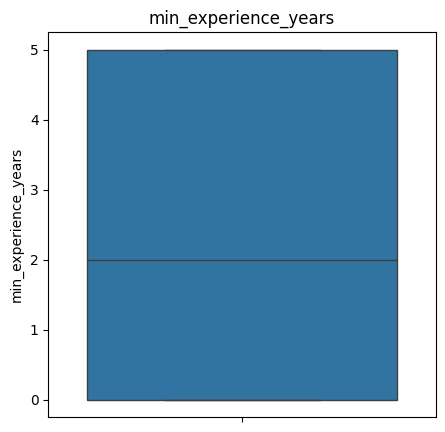

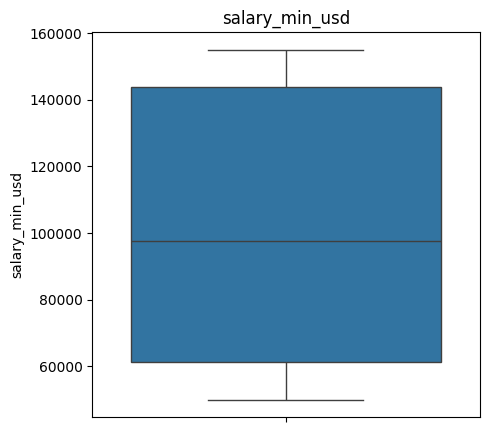

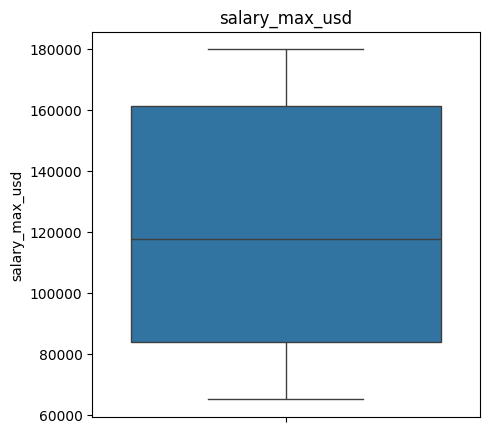

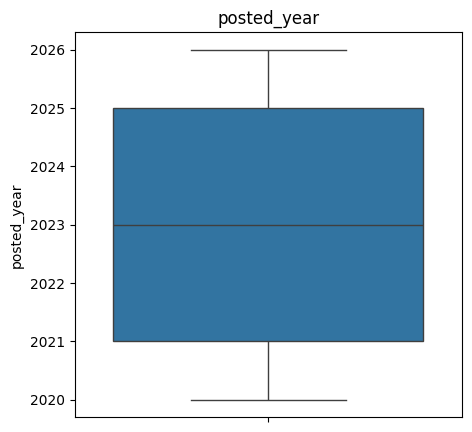

In [ ]:
#outliers detect
for cols in numeric_cols:
  plt.figure(figsize=(5,5))
  sns.boxplot(df[cols])
  plt.title(cols)
  plt.show()

=> The boxplots show that all numerical features are well distributed without any significant outliers. The data lies within expected ranges, indicating consistency and good data quality. Therefore, no outlier treatment was required.

# **Exploratory Data Analysis (EDA)**

## **1. Statistical**

In [ ]:
#for nummeric cols
df[numeric_cols].describe()

,min_experience_years,salary_min_usd,salary_max_usd,posted_year
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,2.335500,100871.434320,120858.350740,2022.996360
std,2.054172,37043.446641,37531.386484,2.001286
min,0.000000,50000.000000,65000.000000,2020.000000
25%,0.000000,61287.000000,83739.000000,2021.000000
50%,2.000000,97505.000000,117604.000000,2023.000000
75%,5.000000,143730.500000,161348.750000,2025.000000
max,5.000000,154999.000000,180000.000000,2026.000000


In [ ]:
df[numeric_cols].mean()

,0
min_experience_years,2.33550
salary_min_usd,100871.43432
salary_max_usd,120858.35074
posted_year,2022.99636


-> The mean values represent the overall average of the dataset. The results show that AI jobs require around 2.33 years of experience and offer an average salary range between 100,605 and 120,802.

In [ ]:
df[numeric_cols].median()

,0
min_experience_years,2.0
salary_min_usd,97505.0
salary_max_usd,117604.0
posted_year,2023.0


->  The median represents the middle value of the dataset, showing that most AI jobs require 2 years of experience, offer salaries around 97,053-117,367, and were mostly posted in 2023.


In [ ]:
df[numeric_cols].skew()

,0
min_experience_years,0.237717
salary_min_usd,0.131530
salary_max_usd,0.123519
posted_year,-0.000043


->  The skewness values are close to zero, indicating that the numeric variables in the dataset are approximately normally distributed with very slight positive or negative skewness.


In [ ]:
df[numeric_cols].kurt()

,0
min_experience_years,-1.499832
salary_min_usd,-1.458850
salary_max_usd,-1.392996
posted_year,-1.250348


-> The kurtosis values are negative , indicating that the distribution of the numeric variables is platykurtic (flat with light tails) , meaning the data is flatter with fewer extreme outliers compared to a normal distribution.


In [ ]:
df[numeric_cols].std()

,0
min_experience_years,2.054172
salary_min_usd,37043.446641
salary_max_usd,37531.386484
posted_year,2.001286


-> The standard deviation measures the spread of data around the mean. Here, numeric variables like experience and salary have moderate spread, with salaries varying by around 37,000 and experience by about 2 years , while posted years vary by about 2 years.

In [ ]:
#for categorical cols
print("Counts of",df['industry'].value_counts())
print("-----------------------------------")
print("\nCounts of",df['experience_level'].value_counts())
print("-----------------------------------")
print("\nCounts of",df['remote_type'].value_counts())
print("-----------------------------------")
print("\nCounts of",df['company_size'].value_counts())
print("-----------------------------------")
print("\nCounts of",df['employment_type'].value_counts())
print("-----------------------------------")

Counts of industry
Tech          10083
Healthcare    10029
Retail         9979
Finance        9970
Education      9939
Name: count, dtype: int64
-----------------------------------

Counts of experience_level
Mid       16695
Senior    16677
Entry     16628
Name: count, dtype: int64
-----------------------------------

Counts of remote_type
Hybrid    16984
Onsite    16538
Remote    16478
Name: count, dtype: int64
-----------------------------------

Counts of company_size
Medium    16679
Small     16667
Large     16654
Name: count, dtype: int64
-----------------------------------

Counts of employment_type
Full-time    50000
Name: count, dtype: int64
-----------------------------------


# **2. Graphical**

## => Univariate analysis

---

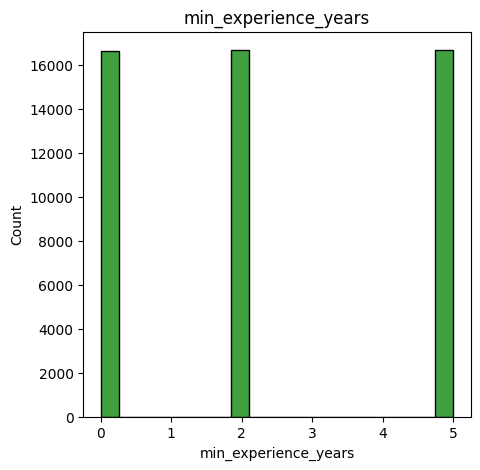

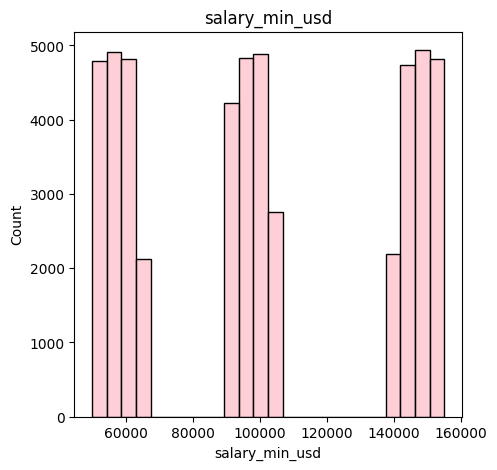

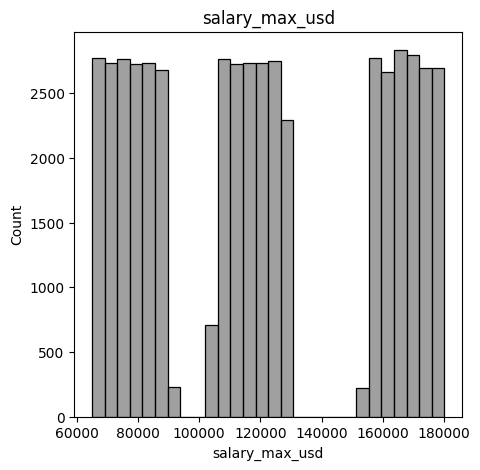

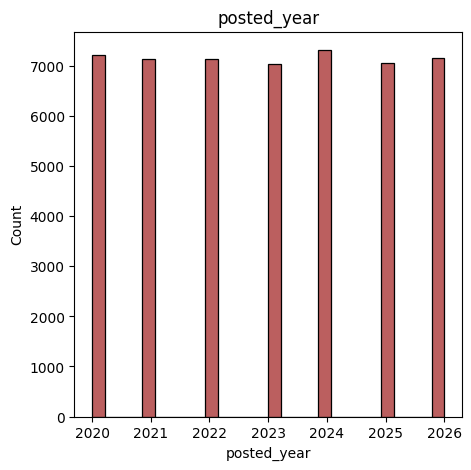

In [ ]:
#univariate analysis for numeric cols
numeric_eda = ['min_experience_years','salary_min_usd','salary_max_usd','posted_year']
colors = ['green','pink','gray','brown']

for col, c in zip(numeric_eda, colors):
    plt.figure(figsize=(5,5))
    sns.histplot(df[col], color=c)
    plt.title(col)
    plt.show()


->The min experience years distribution shows that most jobs require 0 to 5 years of experience, with many positions available for entry-level and early-career professionals.

-> The minimum salary distribution shows three main salary groups, indicating different starting salaries for entry-level, mid-level, and senior roles.

-> The maximum salary distribution has a wider range, showing that companies offer flexible upper salary limits depending on experience, skills, and job responsibilities.

-> Job postings remain relatively consistent from 2020 to 2026, with a slight increase in recent years, indicating steady demand for AI professionals.

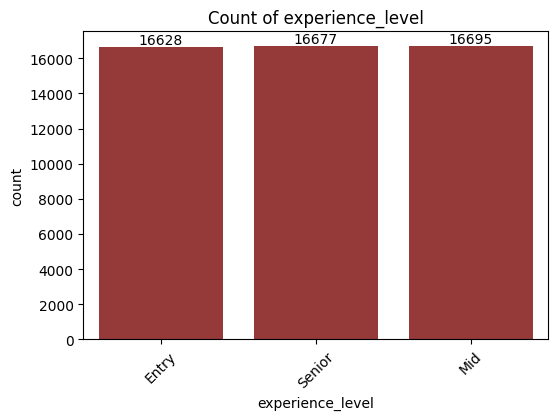

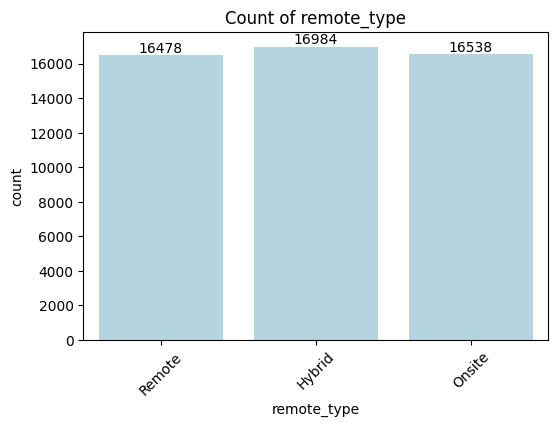

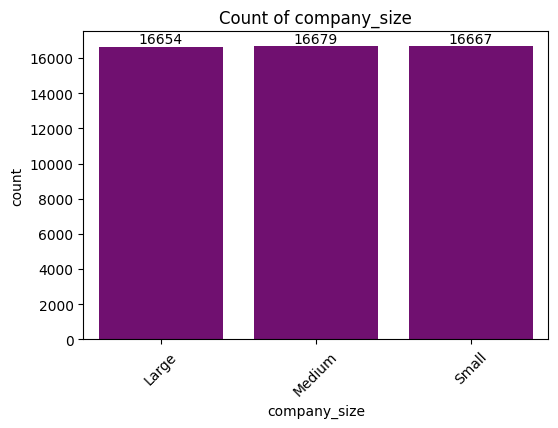

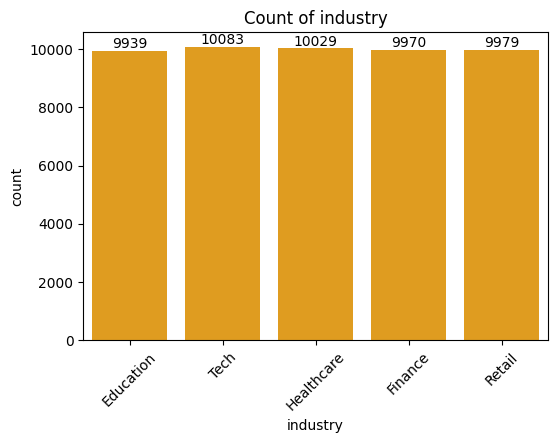

In [ ]:
#univariate analysis for categorical cols
cat_cols = ['experience_level','remote_type','company_size','industry']
colors = ['brown','lightblue','purple','orange','green','pink']

for col, c in zip(cat_cols, colors):
    plt.figure(figsize=(6,4))
    ax=sns.countplot(x=col, data=df, color=c)
    #for display count using bar_label
    for container in ax.containers:
      ax.bar_label(container)
    plt.xticks(rotation=45)
    plt.title(f"Count of {col}")
    plt.show()

## => Bivariate analysis

---

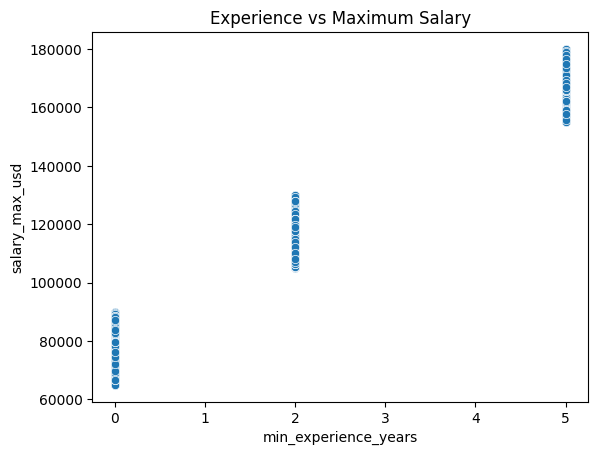

In [ ]:
#scatter of min experience year and salary max usd [numeric vs numeic]
sns.scatterplot(x='min_experience_years', y='salary_max_usd', data=df)
plt.title("Experience vs Maximum Salary")
plt.show()

-> The graph shows that There is a positive relationship between experience and salary. Jobs with 0 years experience have lower salaries, while jobs requiring 2-5 years experience offer much higher salaries.

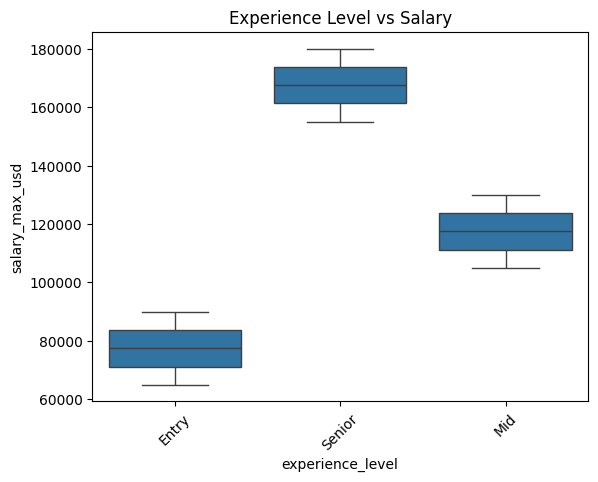

In [ ]:
#box plot of experience level and salary max usd [categorical vs numeric]
sns.boxplot(x='experience_level', y='salary_max_usd', data=df)
plt.title("Experience Level vs Salary")
plt.xticks(rotation=45)
plt.show()

-> The boxplot shows that as the experience level increases from Entry ,  Mid and Senior, the salary also increases significantly, showing that higher experience leads to better salary opportunities in AI-related jobs.

                      min_experience_years  salary_min_usd  salary_max_usd  \
min_experience_years              1.000000        0.991867        0.980046   
salary_min_usd                    0.991867        1.000000        0.974541   
salary_max_usd                    0.980046        0.974541        1.000000   
posted_year                      -0.004057       -0.003718       -0.005150   

                      posted_year  
min_experience_years    -0.004057  
salary_min_usd          -0.003718  
salary_max_usd          -0.005150  
posted_year              1.000000  


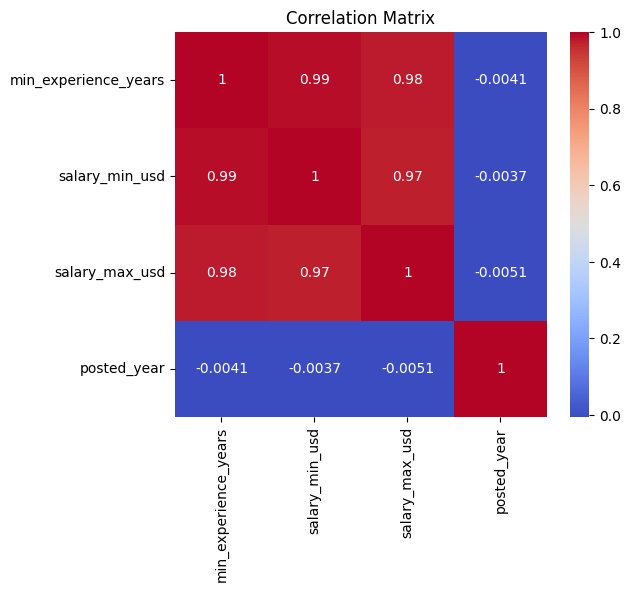

In [ ]:
# Calculate correlation
corr_matrix = df[numeric_cols].corr()

print(corr_matrix)
# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

-> This graph shows that salary strongly increases with experience, while the year the job was posted does not significantly affect salary or experience requirements.

## => Multivariate analysis

---

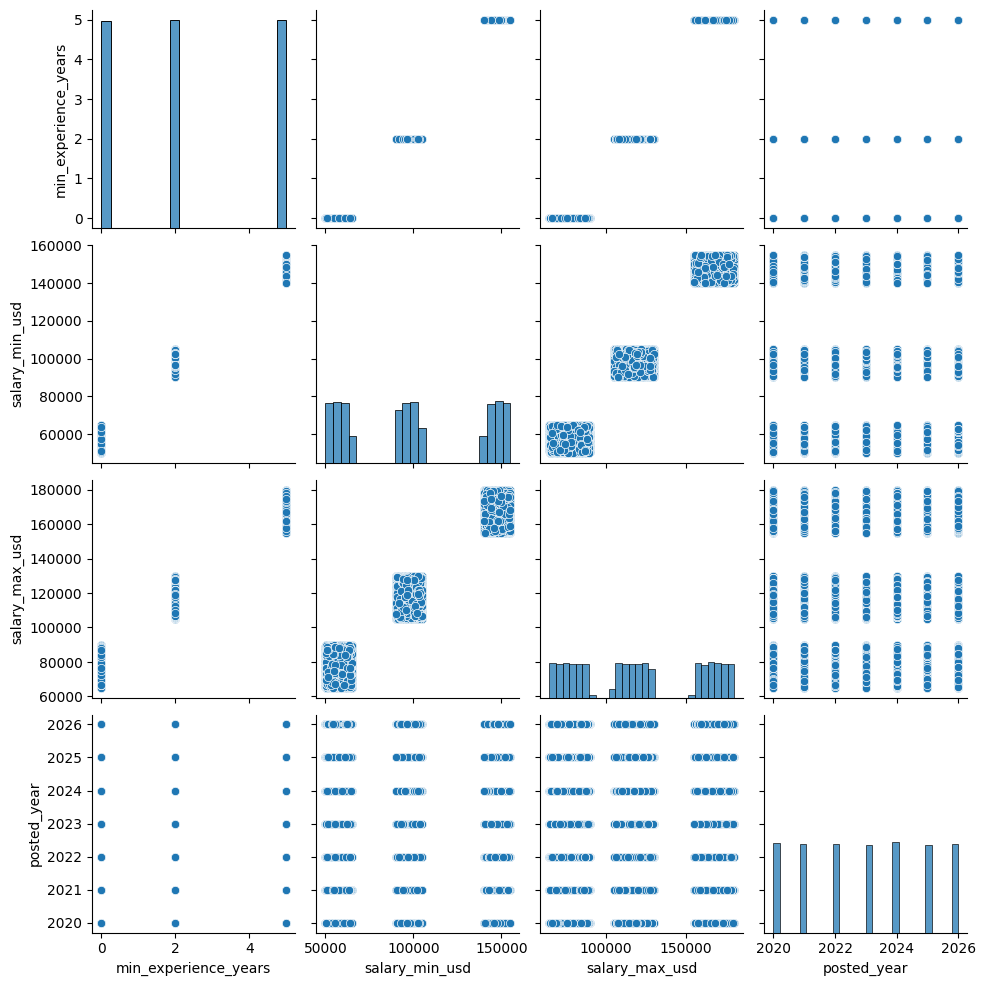

In [ ]:
#pair plot
sns.pairplot(df[numeric_cols])
plt.show()

=> Multivariate analysis was performed using a pairplot to understand relationships among multiple numerical variables simultaneously. The analysis confirms that salary is positively influenced by experience, while other variables show weaker relationships. It helps in validating feature selection and understanding how multiple factors together impact salary prediction.

# **Feature Engineering**

Creating avg_Salary based on min_salary_usd and max_Salary_usd

In [ ]:
df['avg_salary'] = (df['salary_min_usd'] + df['salary_max_usd']) / 2

                      min_experience_years  posted_year  avg_salary
min_experience_years              1.000000    -0.004057    0.992254
posted_year                      -0.004057     1.000000   -0.004467
avg_salary                        0.992254    -0.004467    1.000000


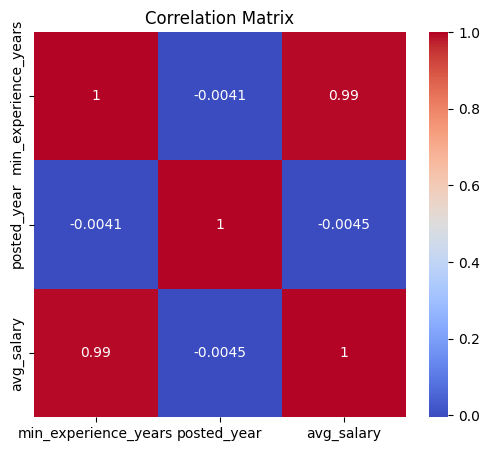

In [ ]:
numeric_cols = ['min_experience_years','posted_year','avg_salary']

corr_matrix = df[numeric_cols].corr()

corr_matrix = df[numeric_cols].corr()

print(corr_matrix)


plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Select Features and Targets

In [ ]:
X = df[['experience_level', 'min_experience_years', 'company_size', 'posted_year']]

y = df['avg_salary']

Encode Categorical Data

In [ ]:
# Encode ordinal columns (order matters)
ordinal_cols  = ['experience_level', 'company_size']
ordinal_order = [
    ['Entry', 'Mid', 'Senior'],
    ['Small', 'Medium', 'Large']
]

preprocessor = ColumnTransformer([
    ('ordinal', OrdinalEncoder(categories=ordinal_order), ordinal_cols),
], remainder='passthrough')

print("Preprocessor defined. Features:", list(X.columns))

Preprocessor defined. Features: ['experience_level', 'min_experience_years', 'company_size', 'posted_year']


Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

X_train_enc = preprocessor.fit_transform(X_train)  # fit on train only
X_test_enc  = preprocessor.transform(X_test)       # transform only on test

print(f"X_train_enc shape: {X_train_enc.shape}")
print(f"X_test_enc  shape: {X_test_enc.shape}")

X_train_enc shape: (40000, 4)
X_test_enc  shape: (10000, 4)


Train Models

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_enc, y_train)
y_pred_lr = lr_model.predict(X_test_enc)

dt_model = DecisionTreeRegressor(
    max_depth=5, min_samples_leaf=10,  # prevents overfit
    random_state=42)
dt_model.fit(X_train_enc, y_train)
y_pred_dt = dt_model.predict(X_test_enc)

rf_model = RandomForestRegressor(
    n_estimators=100, max_depth=10, min_samples_leaf=5,
    n_jobs=-1, random_state=42)
rf_model.fit(X_train_enc, y_train)
y_pred_rf = rf_model.predict(X_test_enc)

Model Evaluation

Use:

MAE

RMSE

R² Score

In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})
print(results)

               Model          MAE         RMSE  R2 Score
0  Linear Regression  3522.342039  4221.732404  0.986945
1      Decision Tree  3522.864692  4222.182692  0.986943
2      Random Forest  3524.870129  4223.740337  0.986933


=> Linear Regression was selected as the final model because it achieved the best performance among all models, with the lowest MAE and RMSE and the highest R² score. This indicates that it provides the most accurate and reliable salary predictions for the given dataset.

**Overfit Check**

In [ ]:
print("\n--- Overfit check ---")
model_objs = {
    'Linear Regression': lr_model,
    'Decision Tree'    : dt_model,
    'Random Forest'    : rf_model
}
for name, model in model_objs.items():
    train_r2 = r2_score(y_train, model.predict(X_train_enc))
    test_r2  = r2_score(y_test,  model.predict(X_test_enc))
    gap      = round(train_r2 - test_r2, 4)
    status   = "OK" if gap < 0.02 else "OVERFIT!"
    print(f"{name:20s}  train-r2={train_r2:.4f}  test-r2={test_r2:.4f}  gap={gap}  {status}")


--- Overfit check ---
Linear Regression     train-r2=0.9872  test-r2=0.9869  gap=0.0003  OK
Decision Tree         train-r2=0.9872  test-r2=0.9869  gap=0.0003  OK
Random Forest         train-r2=0.9872  test-r2=0.9869  gap=0.0003  OK


=> The overfitting check shows that the difference between training and testing R² scores is extremely small for all models. This indicates that the models are well generalized and do not suffer from overfitting. Therefore, the Linear Regression Model is reliable and perform consistently on unseen data.

**Feature Importance**

In [ ]:
ordinal_cols  = ['experience_level', 'company_size']
passthrough   = ['min_experience_years', 'posted_year']

feature_names = ordinal_cols + passthrough

print("All encoded features:")
for i, name in enumerate(feature_names, 1):
    print(f"  {i:2d}. {name}")

All encoded features:
   1. experience_level
   2. company_size
   3. min_experience_years
   4. posted_year


In [ ]:
# calculate and print feature importance
importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Add percentage column for readability
importance_df['Importance %'] = (importance_df['Importance'] * 100).round(2)

print("===== Feature Importance — Random Forest =====")
print(importance_df[['Feature', 'Importance %']].to_string(index=False))

===== Feature Importance — Random Forest =====
             Feature  Importance %
    experience_level          54.6
min_experience_years          45.4
         posted_year           0.0
        company_size           0.0


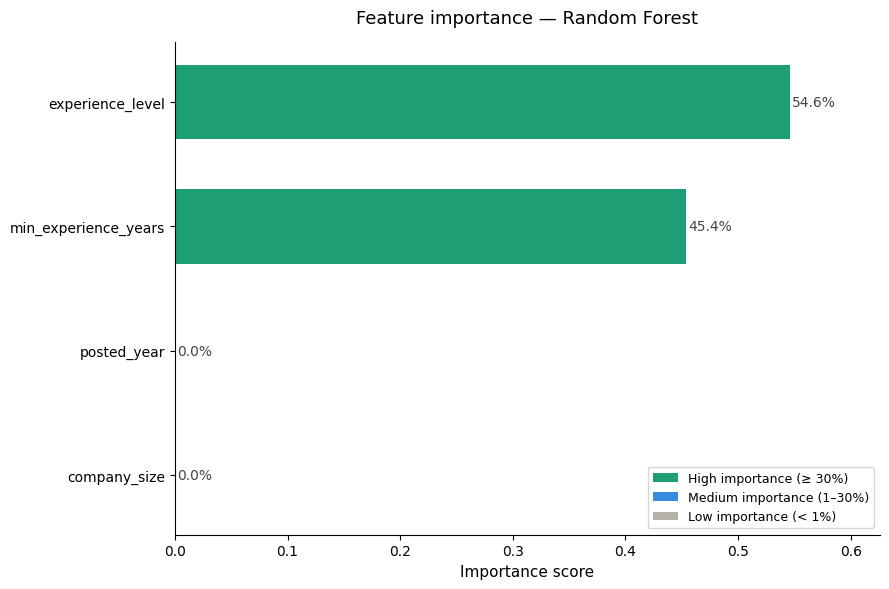

In [ ]:
imp_sorted = importance_df.sort_values('Importance', ascending=True)

# Colour bars by importance tier
colors = []
for val in imp_sorted['Importance']:
    if   val >= 0.30: colors.append('#1D9E75')  # high  → teal
    elif val >= 0.01: colors.append('#378ADD')  # medium → blue
    else:             colors.append('#B4B2A9')  # low   → gray

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    imp_sorted['Feature'],
    imp_sorted['Importance'],
    color=colors,
    edgecolor='none',
    height=0.6
)

# Add percentage labels at end of each bar
for bar, val in zip(bars, imp_sorted['Importance']):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val*100:.1f}%",
        va='center', ha='left',
        fontsize=10, color='#444441'
    )

# Legend for colour tiers
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1D9E75', label='High importance (≥ 30%)'),
    Patch(facecolor='#378ADD', label='Medium importance (1–30%)'),
    Patch(facecolor='#B4B2A9', label='Low importance (< 1%)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_xlabel('Importance score', fontsize=11)
ax.set_title('Feature importance — Random Forest', fontsize=13, pad=14)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
ax.set_xlim(0, imp_sorted['Importance'].max() + 0.08)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

=> "This dataset does not capture company-name-level salary variation. In a real-world dataset containing actual company names, stock compensation, and location-adjusted salaries, features like company size and industry would contribute significantly to prediction accuracy."

Actual vs Predicted

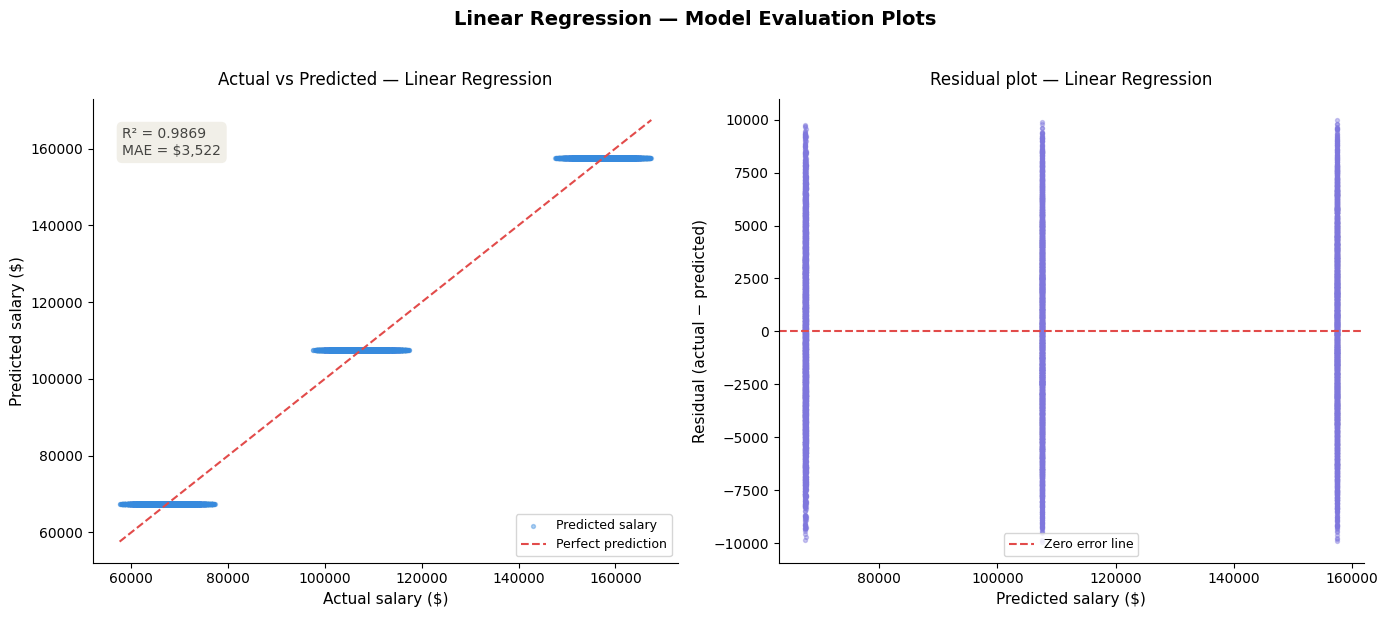

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Plot 1: Actual vs Predicted scatter ────────────────────────
ax1 = axes[0]

ax1.scatter(
    y_test, y_pred_lr,
    alpha=0.4, s=8,
    color='#378ADD',
    label='Predicted salary'
)

# Perfect prediction diagonal line
lims = [y_test.min(), y_test.max()]
ax1.plot(lims, lims,
         color='#E24B4A', linewidth=1.5,
         linestyle='--', label='Perfect prediction')

# Labels and formatting
ax1.set_xlabel('Actual salary ($)', fontsize=11)
ax1.set_ylabel('Predicted salary ($)', fontsize=11)
ax1.set_title('Actual vs Predicted — Linear Regression', fontsize=12, pad=10)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# Add R² annotation inside plot
r2  = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
ax1.annotate(
    f'R² = {r2:.4f}\nMAE = ${mae:,.0f}',
    xy=(0.05, 0.88), xycoords='axes fraction',
    fontsize=10, color='#444441',
    bbox=dict(boxstyle='round,pad=0.4',
               facecolor='#F1EFE8', edgecolor='none')
)

# ── Plot 2: Residual plot ──────────────────────────────────────
ax2 = axes[1]

residuals = y_test.values - y_pred_lr

ax2.scatter(
    y_pred_lr, residuals,
    alpha=0.4, s=8,
    color='#7F77DD'
)

# Zero reference line
ax2.axhline(0, color='#E24B4A',
            linewidth=1.5, linestyle='--',
            label='Zero error line')

ax2.set_xlabel('Predicted salary ($)', fontsize=11)
ax2.set_ylabel('Residual (actual − predicted)', fontsize=11)
ax2.set_title('Residual plot — Linear Regression', fontsize=12, pad=10)
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    'Linear Regression — Model Evaluation Plots',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('lr_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

=> The Actual vs Predicted plot shows that the predicted salaries closely match the actual values, indicating high model accuracy. The residual plot demonstrates that errors are randomly distributed around zero, confirming that the model is unbiased and well-fitted. Overall, the Linear Regression model performs very effectively for salary prediction.

**Complete Prediction**

In [ ]:
def predict_ai_salary(experience_level, min_experience_years,
                        company_size='Medium', posted_year=2025):

# Validate inputs
    valid_exp   = ['Entry', 'Mid', 'Senior']
    valid_size  = ['Small', 'Medium', 'Large']
    valid_years = {'Entry': 0, 'Mid': 2, 'Senior': 5}

    if experience_level not in valid_exp:
        raise ValueError(f"experience_level must be one of {valid_exp}")
    if company_size not in valid_size:
        raise ValueError(f"company_size must be one of {valid_size}")
    if min_experience_years != valid_years[experience_level]:
        print(f"Note: for {experience_level}, expected {valid_years[experience_level]} years.")

  # Build input
    profile = pd.DataFrame([{
        'experience_level'    : experience_level,
        'min_experience_years': min_experience_years,
        'company_size'        : company_size,
        'posted_year'         : posted_year
    }])

    # Encode and predict
    X_input   = preprocessor.transform(profile)
    predicted = lr_model.predict(X_input)[0]
    mae       = 3522

# Print result
    print(f"\n--- AI/ML Salary Prediction ---")
    print(f"Experience level : {experience_level}")
    print(f"Years of exp     : {min_experience_years}")
    print(f"Predicted salary : ${predicted:,.2f}")
    print(f"Confidence range : ${predicted-mae:,.0f}  –  ${predicted+mae:,.0f}")
    print(f"Scope            : Valid for AI/ML roles only")
    print(f"-------------------------------")

    return round(predicted, 2)


predict_ai_salary('Senior',  10)   # Input Exp level and Exp years to get predicted salary

Note: for Senior, expected 5 years.

--- AI/ML Salary Prediction ---
Experience level : Senior
Years of exp     : 10
Predicted salary : $206,957.66
Confidence range : $203,436  –  $210,480
Scope            : Valid for AI/ML roles only
-------------------------------


np.float64(206957.66)

In [ ]:
def get_salary_prediction():
    print("=========================================")
    print("        AI/ML Salary Predictor")
    print("=========================================")

    # ── Input 1: Experience Level ──────────────
    valid_exp = ['Entry', 'Mid', 'Senior']
    print("\nExperience levels:")
    print("  1. Entry  (0 years)")
    print("  2. Mid    (2 years)")
    print("  3. Senior (5 years)")

    while True:
        exp_lvl = input("\nEnter experience level (Entry / Mid / Senior): ").strip().capitalize()
        if exp_lvl in valid_exp:
            break
        print(f"  Invalid. Choose from: {valid_exp}")

    # ── Input 2: Years of Experience ───────────
    expected_yrs = {'Entry': 0, 'Mid': 2, 'Senior': 5}
    while True:
        try:
            exp_yrs = int(input(f"Enter years of experience (recommended: {expected_yrs[exp_lvl]}): "))
            if 0 <= exp_yrs <= 30:
                break
            print("  Please enter a number between 0 and 30.")
        except ValueError:
            print("  Please enter a valid number.")

    if exp_yrs != expected_yrs[exp_lvl]:
        print(f"  Note: model trained on {expected_yrs[exp_lvl]} yr(s) for {exp_lvl}.")

    # ── Input 3: Company Size ──────────────────
    valid_size = ['Small', 'Medium', 'Large']
    while True:
        comp_size = input("Enter company size (Small / Medium / Large) [default: Medium]: ").strip().capitalize()
        if comp_size == '':
            comp_size = 'Medium'
            break
        if comp_size in valid_size:
            break
        print(f"  Invalid. Choose from: {valid_size}")

    # ── Predict ────────────────────────────────
    predict_ai_salary(exp_lvl, exp_yrs, comp_size)


# Run it
get_salary_prediction()

        AI/ML Salary Predictor

Experience levels:
  1. Entry  (0 years)
  2. Mid    (2 years)
  3. Senior (5 years)
